In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import numpy as np

In [4]:
file_path = 'Student_Performance.csv'

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nikhil7280/student-performance-multiple-linear-regression",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/var/folders/9b/2fjcrmgn6cn8c66zrqxjrw780000gn/T/ipykernel_73047/4061893741.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [6]:
df.shape

(10000, 6)

In [51]:
features = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']].copy()
X_mean = features.mean(axis=0)
X_std = features.std(axis=0)
X_scaled = (features - X_mean) / X_std

X_scaled['Extracurricular Activities'] = features['Extracurricular Activities'].replace({'Yes': 1, 'No': 0}).fillna(0).astype(int)

y = df[['Performance Index']]

m, n = X_scaled.shape
X_scaled.shape, y.shape

((10000, 5), (10000, 1))

In [52]:
def loss_function(y, y_pred):
    return (1 / m) * np.sum((y_pred - y) ** 2)

In [53]:
def calc_gradient(X, y, y_pred, w, b):
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for idx in range(m):
        error = y_pred[idx] - y[idx]
        dj_dw += error * X[idx]
        dj_db += error

    dj_dw *= (2 / m)
    dj_db *= (2 / m)

    return dj_dw, dj_db

In [54]:
def predict(X, w, b):
    predictions = np.zeros(m)

    for idx in range(m):
        predictions[idx] = np.dot(X[idx], w) + b

    return predictions

In [59]:
def train(X, y, w, b, learning_rate=0.001, epochs=1000, history_interval=100):
    history = {}
    for epoch in range(epochs):
        y_pred = predict(X, w, b)
        dj_dw, dj_db = calc_gradient(X, y, y_pred, w, b)
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db
        
        if epoch % history_interval == 0:
            mse = loss_function(y, y_pred)
            history[epoch] = mse
            print(f"${epoch}/{epochs}: MSE = {mse}")

    return w, b, history

In [65]:
w, b = np.zeros(n), 0

w_new, b_new, history = train(X_scaled.values, y.values.flatten(), w, b, learning_rate=0.01, epochs=1000)

$0/1000: MSE = 3418.864
$100/1000: MSE = 64.51137913333388
$200/1000: MSE = 5.30958552126906
$300/1000: MSE = 4.263989623615991
$400/1000: MSE = 4.245508908216853
$500/1000: MSE = 4.24518200082166
$600/1000: MSE = 4.245176213080386
$700/1000: MSE = 4.245176110514851
$800/1000: MSE = 4.2451761086954285
$900/1000: MSE = 4.245176108663118


In [64]:
import matplotlib.pyplot as plt

In [70]:
def plot_true_vs_preds(X, y, w, b):
    y_hat = predict(X, w, b)
    plt.figure(figsize=(5, 5))
    plt.scatter(y, y_hat, alpha=0.3, s=10)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='perfect fit')
    plt.title('True vs Predicted')
    plt.xlabel('y_true')
    plt.ylabel('y_pred')
    plt.legend()

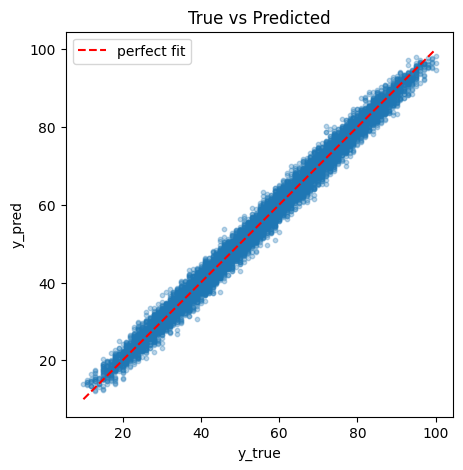

In [71]:
plot_true_vs_preds(X_scaled.values, y.values.flatten(), w_new, b_new)